# Automated Life Insurance Underwriting & Risk Classification
**Dataset:** Prudential Life Insurance Assessment (Kaggle Official Dataset).
**Dimensi Data:** 59.381 aplikasi asuransi jiwa dengan 128 variabel (fitur demografis, riwayat medis, dan produk asuransi).

Notebook ini membangun pipeline klasifikasi risiko underwriting otomatis untuk mempercepat proses persetujuan polis asuransi jiwa. Evaluasi metrik mengoptimalkan Quadratic Weighted Kappa (QWK) menggunakan regresi ordinal dengan ambang batas teroptimasi (*threshold optimization*).

### Arsitektur Pipeline Analisis:
1. **Data Ingestion & Artifact Cleaning**: Pemuatan dataset `train.csv` (59.381 baris, 128 fitur) dan identifikasi kolom dengan missing values tinggi.
2. **Underwriting Exploratory Data Analysis (EDA)**: Profiling variabel risiko kunci (BMI, Usia Tertanggung `Ins_Age`, Riwayat Medis) terhadap kelas risiko 1-8.
3. **Zero-Leakage Preprocessing & Feature Engineering**: Encoding variabel kategorikal (`Product_Info_2`), imputasi median fit hanya pada train-set, dan pembentukan interaksi risiko (`BMI * Ins_Age`).
4. **Machine Learning Model Training**: Baseline Stratified Random Classifier, Multi-class LightGBM Classifier, dan Ordinal LightGBM Regressor dengan optimasi batas potong (*Nelder-Mead Cutoff Optimization*).
5. **Actuarial & Statistical Evaluation**: Perbandingan metrik Quadratic Weighted Kappa (QWK), Multiclass Macro F1-Score, dan visualisasi Confusion Matrix 300 DPI ke `images/`.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize

from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, f1_score, confusion_matrix, classification_report
import lightgbm as lgb

os.makedirs('images', exist_ok=True)
os.makedirs('data', exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.titlesize': 15,
    'figure.figsize': (12, 6)
})

print("Konfigurasi pustaka dan direktori visualisasi berhasil diinisialisasi.")

Konfigurasi pustaka dan direktori visualisasi berhasil diinisialisasi.


In [2]:
df = pd.read_csv('data/train.csv')

print(f"Dimensi data pelatihan: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print("\nDistribusi Target Kelas Risiko (Response):")
print(df['Response'].value_counts().sort_index())

# Identifikasi missing values per variabel
missing = df.isnull().sum()
missing_ratio = (missing[missing > 0] / len(df)).sort_values(ascending=False)
print("\nVariabel dengan rasio missing value tertinggi:")
print(missing_ratio.head(10))
df.head()

Dimensi data pelatihan: 59,381 baris x 128 kolom

Distribusi Target Kelas Risiko (Response):
Response
1     6207
2     6552
3     1013
4     1428
5     5432
6    11233
7     8027
8    19489
Name: count, dtype: int64

Variabel dengan rasio missing value tertinggi:
Medical_History_10     0.990620
Medical_History_32     0.981358
Medical_History_24     0.935990
Medical_History_15     0.751015
Family_Hist_5          0.704114
Family_Hist_3          0.576632
Family_Hist_2          0.482579
Insurance_History_5    0.427679
Family_Hist_4          0.323066
Employment_Info_6      0.182786
dtype: float64


,Id,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,...,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response
0,2,1,D3,10,0.076923,2,1,1,0.641791,0.581818,...,0,0,0,0,0,0,0,0,0,8
1,5,1,A1,26,0.076923,2,3,1,0.059701,0.600000,...,0,0,0,0,0,0,0,0,0,4
2,6,1,E1,26,0.076923,2,3,1,0.029851,0.745455,...,0,0,0,0,0,0,0,0,0,8
3,7,1,D4,10,0.487179,2,3,1,0.164179,0.672727,...,0,0,0,0,0,0,0,0,0,8
4,8,1,D2,26,0.230769,2,3,1,0.417910,0.654545,...,0,0,0,0,0,0,0,0,0,8


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8352\2704272035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Response', palette='Blues_r', ax=axes[0, 0])


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8352\2704272035.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Response', y='BMI', palette='coolwarm', ax=axes[0, 1])


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8352\2704272035.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Response', y='Ins_Age', palette='viridis', ax=axes[1, 0])


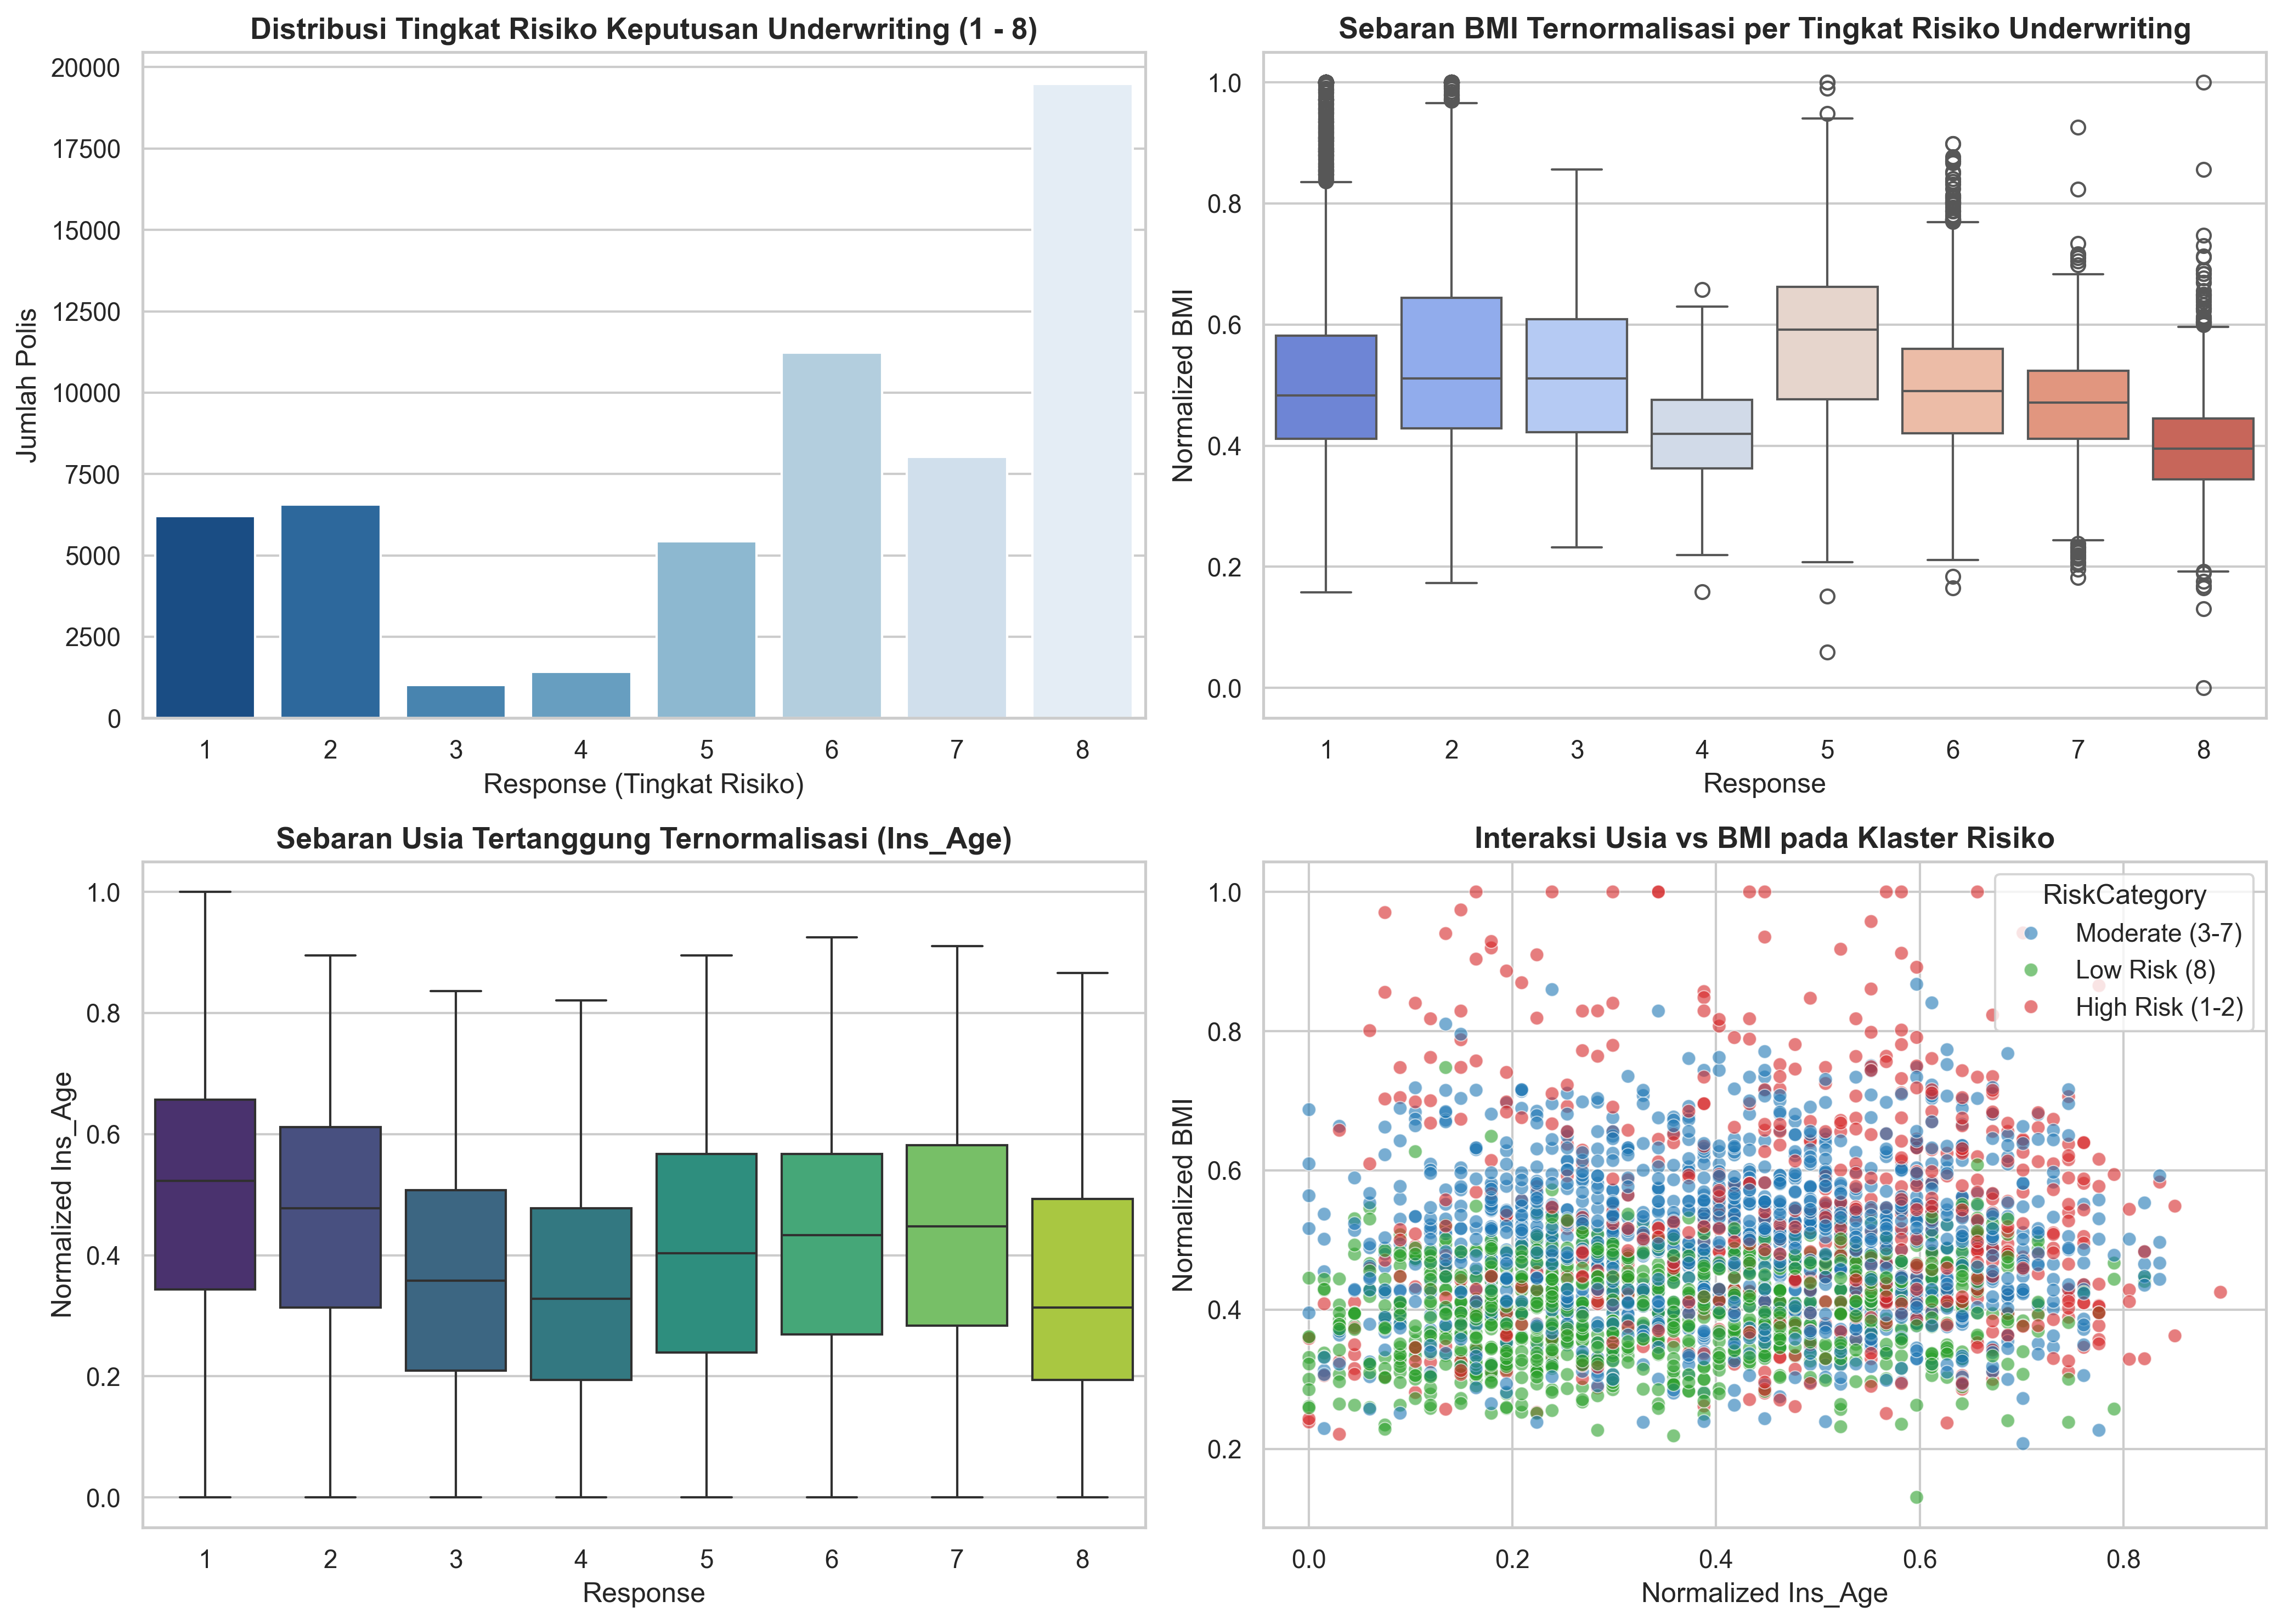

Grafik profil risiko underwriting berhasil diekspor ke images/underwriting_risk_eda.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribusi Kelas Target Risiko Underwriting (Response)
sns.countplot(data=df, x='Response', palette='Blues_r', ax=axes[0, 0])
axes[0, 0].set_title('Distribusi Tingkat Risiko Keputusan Underwriting (1 - 8)', fontweight='bold')
axes[0, 0].set_xlabel('Response (Tingkat Risiko)')
axes[0, 0].set_ylabel('Jumlah Polis')

# 2. Hubungan BMI (Body Mass Index) terhadap Tingkat Risiko
sns.boxplot(data=df, x='Response', y='BMI', palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Sebaran BMI Ternormalisasi per Tingkat Risiko Underwriting', fontweight='bold')
axes[0, 1].set_xlabel('Response')
axes[0, 1].set_ylabel('Normalized BMI')

# 3. Hubungan Usia Tertanggung (Ins_Age) terhadap Tingkat Risiko
sns.boxplot(data=df, x='Response', y='Ins_Age', palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title('Sebaran Usia Tertanggung Ternormalisasi (Ins_Age)', fontweight='bold')
axes[1, 0].set_xlabel('Response')
axes[1, 0].set_ylabel('Normalized Ins_Age')

# 4. Interaksi BMI vs Usia Tertanggung Berdasarkan Kategori Risiko Rendah (8) vs Tinggi (1-2)
df['RiskCategory'] = np.where(df['Response'] == 8, 'Low Risk (8)', np.where(df['Response'] <= 2, 'High Risk (1-2)', 'Moderate (3-7)'))
sns.scatterplot(data=df.sample(3000, random_state=42), x='Ins_Age', y='BMI', hue='RiskCategory', alpha=0.6, palette={'Low Risk (8)': '#2ca02c', 'High Risk (1-2)': '#d62728', 'Moderate (3-7)': '#1f77b4'}, ax=axes[1, 1])
axes[1, 1].set_title('Interaksi Usia vs BMI pada Klaster Risiko', fontweight='bold')
axes[1, 1].set_xlabel('Normalized Ins_Age')
axes[1, 1].set_ylabel('Normalized BMI')

plt.tight_layout()
plt.savefig('images/underwriting_risk_eda.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafik profil risiko underwriting berhasil diekspor ke images/underwriting_risk_eda.png")

In [4]:
# Preprocessing & Feature Engineering Terisolasi (Mencegah Data Leakage)
# Pisahkan fitur dan target
X = df.drop(columns=['Id', 'Response', 'RiskCategory'], errors='ignore').copy()
y = df['Response'].values

# Ekstraksi fitur kategorikal Product_Info_2 menjadi komponen huruf dan angka
X['Product_Info_2_Char'] = X['Product_Info_2'].str[0].astype('category').cat.codes
X['Product_Info_2_Num'] = X['Product_Info_2'].str[1].astype(int)
X = X.drop(columns=['Product_Info_2'])

# Feature Engineering: Rekayasa fitur risiko gabungan
X['BMI_Age_Interaction'] = X['BMI'] * X['Ins_Age']
X['Medical_Keyword_Sum'] = X[[c for c in X.columns if c.startswith('Medical_Keyword_')]].sum(axis=1)

# Holdout Split Terisolasi (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Imputasi nilai hilang menggunakan median yang difit HANYA pada X_train
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print(f"Ukuran sampel pelatihan: {X_train.shape[0]:,} observasi x {X_train.shape[1]} fitur")
print(f"Ukuran sampel pengujian: {X_test.shape[0]:,} observasi x {X_test.shape[1]} fitur")

Ukuran sampel pelatihan: 47,504 observasi x 129 fitur
Ukuran sampel pengujian: 11,877 observasi x 129 fitur


In [5]:
# Pembangunan Model: Baseline vs Multiclass LightGBM vs Ordinal Regression LightGBM

# 1. Model Baseline: Stratified Dummy Guessing
np.random.seed(42)
prior_probs = pd.Series(y_train).value_counts(normalize=True).sort_index().values
y_pred_baseline = np.random.choice(np.arange(1, 9), size=len(y_test), p=prior_probs)

# 2. Model Klasifikasi Multiclass LightGBM
clf_multi = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=8,
    n_estimators=250,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
clf_multi.fit(X_train, y_train - 1)
y_pred_multi = clf_multi.predict(X_test) + 1

# 3. Model Regresi Ordinal LightGBM dengan Optimasi Batas Potong (Threshold Optimization)
reg_ordinal = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
reg_ordinal.fit(X_train, y_train)
y_pred_cont_train = reg_ordinal.predict(X_train)
y_pred_cont_test = reg_ordinal.predict(X_test)

# Fungsi Evaluasi & Optimizer QWK
class OptimizedRounder:
    def __init__(self):
        self.coef_ = 0

    def _loss(self, coef, X, y):
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]:
                X_p[i] = 1
            elif pred < coef[1]:
                X_p[i] = 2
            elif pred < coef[2]:
                X_p[i] = 3
            elif pred < coef[3]:
                X_p[i] = 4
            elif pred < coef[4]:
                X_p[i] = 5
            elif pred < coef[5]:
                X_p[i] = 6
            elif pred < coef[6]:
                X_p[i] = 7
            else:
                X_p[i] = 8
        return -cohen_kappa_score(y, X_p, weights='quadratic')

    def fit(self, X, y):
        initial_coef = [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]
        res = minimize(self._loss, initial_coef, args=(X, y), method='Nelder-Mead')
        self.coef_ = res.x

    def predict(self, X):
        X_p = np.copy(X)
        res = np.zeros(len(X_p), dtype=int)
        for i, pred in enumerate(X_p):
            if pred < self.coef_[0]:
                res[i] = 1
            elif pred < self.coef_[1]:
                res[i] = 2
            elif pred < self.coef_[2]:
                res[i] = 3
            elif pred < self.coef_[3]:
                res[i] = 4
            elif pred < self.coef_[4]:
                res[i] = 5
            elif pred < self.coef_[5]:
                res[i] = 6
            elif pred < self.coef_[6]:
                res[i] = 7
            else:
                res[i] = 8
        return res

rounder = OptimizedRounder()
rounder.fit(y_pred_cont_train, y_train)
y_pred_ordinal = rounder.predict(y_pred_cont_test)

print(f"Optimasi batas potong ordinal berhasil: {np.round(rounder.coef_, 2)}")

Optimasi batas potong ordinal berhasil: [1.7  3.77 4.27 4.89 5.38 6.14 6.81]


=== HASIL EVALUASI METRIK UNDERWRITING ===
Baseline Random  - QWK: -0.0125 | Macro F1: 0.1166
Multiclass LGBM  - QWK: 0.5639 | Macro F1: 0.5184
Ordinal Opt LGBM - QWK: 0.6495 | Macro F1: 0.2414


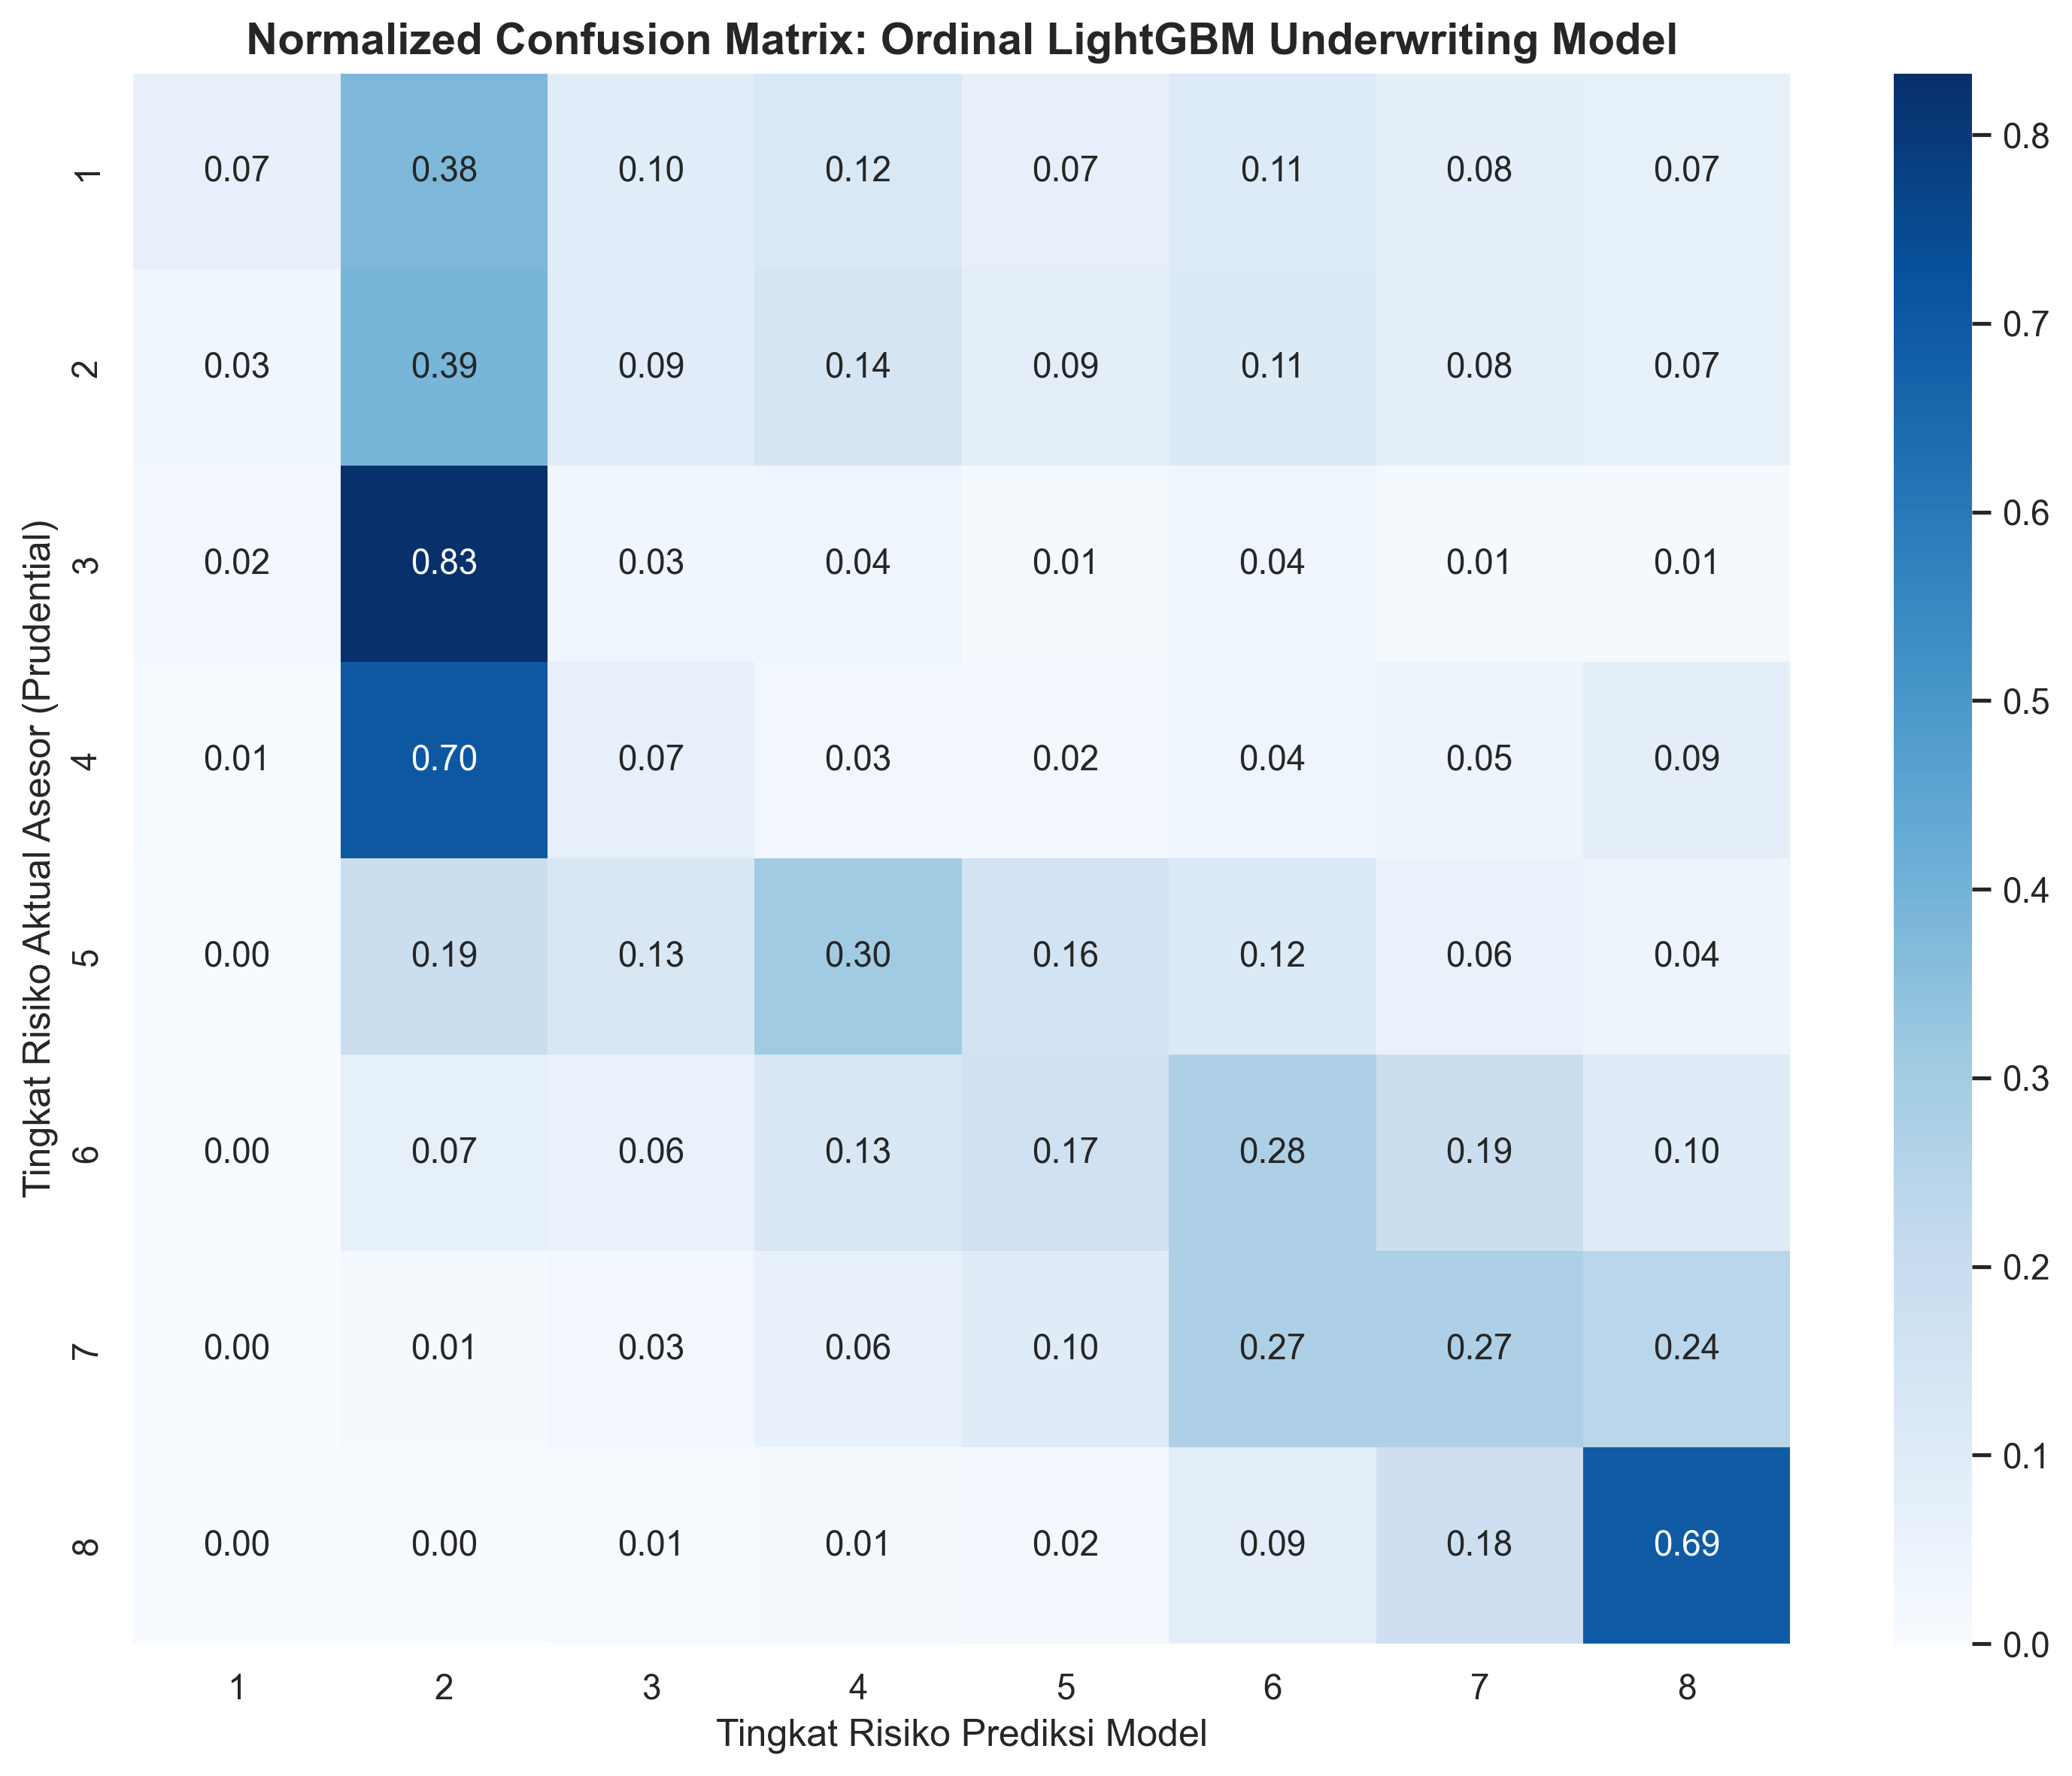

Visualisasi confusion matrix berhasil diekspor ke images/underwriting_confusion_matrix.png


In [6]:
# Evaluasi Kuantitatif: Quadratic Weighted Kappa & Confusion Matrix
qwk_baseline = cohen_kappa_score(y_test, y_pred_baseline, weights='quadratic')
qwk_multi = cohen_kappa_score(y_test, y_pred_multi, weights='quadratic')
qwk_ordinal = cohen_kappa_score(y_test, y_pred_ordinal, weights='quadratic')

f1_baseline = f1_score(y_test, y_pred_baseline, average='macro')
f1_multi = f1_score(y_test, y_pred_multi, average='macro')
f1_ordinal = f1_score(y_test, y_pred_ordinal, average='macro')

print("=== HASIL EVALUASI METRIK UNDERWRITING ===")
print(f"Baseline Random  - QWK: {qwk_baseline:.4f} | Macro F1: {f1_baseline:.4f}")
print(f"Multiclass LGBM  - QWK: {qwk_multi:.4f} | Macro F1: {f1_multi:.4f}")
print(f"Ordinal Opt LGBM - QWK: {qwk_ordinal:.4f} | Macro F1: {f1_ordinal:.4f}")

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_ordinal, labels=np.arange(1, 9))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=np.arange(1, 9), yticklabels=np.arange(1, 9))
plt.title('Normalized Confusion Matrix: Ordinal LightGBM Underwriting Model', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Risiko Prediksi Model')
plt.ylabel('Tingkat Risiko Aktual Asesor (Prudential)')
plt.tight_layout()
plt.savefig('images/underwriting_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualisasi confusion matrix berhasil diekspor ke images/underwriting_confusion_matrix.png")